<a href="https://colab.research.google.com/github/scientificbroker/business-analytics-para-startups/blob/main/Code%20Colabs/M5_Prophet_Forecasting_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M5 — Prophet: Demand Forecasting para Startups LATAM

**Caso de uso:** AgriTech B2B de insumos agrícolas con estacionalidad regional  
*(Inspirado en Agrofy — Argentina/Brasil, Kubo Financiero Agro — México, Agrosmart — Brasil)*

---

## Objetivos del módulo

1. Construir y analizar una serie temporal de ventas con estacionalidad agrícola
2. Entrenar un modelo Prophet con estacionalidades múltiples y eventos LATAM
3. Generar un pronóstico a 6 meses con intervalos de confianza
4. Descomponer la serie en tendencia, estacionalidad y efecto de festivos
5. Evaluar el modelo con MAPE y MAE
6. Producir una tabla de planning mensual (base/pesimista/optimista)

---

**¿Por qué Prophet?**  
Prophet fue diseñado por Meta para analistas de negocio (no solo estadísticos). Maneja automáticamente: tendencias cambiantes, estacionalidades múltiples, festivos y datos faltantes — los cuatro problemas más comunes en series de tiempo de startups LATAM.

**Datos que necesitas:**
- Serie temporal diaria o semanal (mínimo 2 ciclos completos de tu estacionalidad principal)
- Columnas requeridas por Prophet: `ds` (fecha) y `y` (valor a pronosticar)

> **Repositorio:** [business-analytics-para-startups](https://github.com/scientificbroker/business-analytics-para-startups)

## 0. Instalación de dependencias

Prophet requiere instalación adicional — ejecuta la celda de abajo en Google Colab.

In [1]:
# Instala Prophet y dependencias (ejecuta solo una vez en Google Colab)
%pip install prophet pandas numpy matplotlib -q


## 1. Configuración de parámetros

Ajusta el horizonte de pronóstico y los parámetros del modelo.

In [2]:
# ════════════════════════════════════════════════
# PARÁMETROS CONFIGURABLES
# ════════════════════════════════════════════════

FECHA_INICIO_HISTORICO = '2023-01-01'  # inicio de datos históricos
FECHA_FIN_HISTORICO    = '2026-03-31'  # fin de datos históricos (hoy)
SEMANAS_FORECAST       = 26            # 26 semanas = 6 meses hacia adelante

# Parámetros del modelo Prophet
CHANGEPOINT_PRIOR      = 0.15   # flexibilidad de tendencia (0.05=rígida, 0.5=muy flexible)
SEASONALITY_PRIOR      = 10     # fuerza de estacionalidad
INTERVAL_WIDTH         = 0.80   # banda de confianza del 80%

# % de costos sobre el revenue (para la tabla de planning de compras)
COGS_PCT = 0.60  # 60% típico para AgriTech (costo de insumos)

# Para cargar datos reales:
# df_ts = pd.read_csv('ventas_semanales.csv')
# df_ts = df_ts.rename(columns={'fecha': 'ds', 'ventas': 'y'})

## 2. Importaciones

In [3]:
%matplotlib inline
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

try:
    from prophet import Prophet
    from prophet.diagnostics import cross_validation, performance_metrics
    PROPHET_OK = True
    print('Prophet instalado correctamente.')
except ImportError:
    PROPHET_OK = False
    print('Prophet no instalado.')
    print('En Google Colab ejecuta: %pip install prophet')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('seaborn-whitegrid')
plt.rcParams.update({'figure.figsize': (14, 6), 'font.size': 11,
                     'axes.titlesize': 13, 'axes.titleweight': 'bold'})
np.random.seed(42)

print('Modulo 5: Prophet — Demand Forecasting AgriTech LATAM')
print('Similar a: Agrofy, Kubo Agro, Agrosmart, Granular')


Prophet instalado correctamente.
Modulo 5: Prophet — Demand Forecasting AgriTech LATAM
Similar a: Agrofy, Kubo Agro, Agrosmart, Granular


## 3. Serie temporal con estacionalidad agrícola LATAM

La demanda de insumos agrícolas en LATAM tiene **dos picos por año** claramente marcados:
- **Q3-Q4 (siembra):** preparación de tierra, compra de semillas y fertilizantes
- **Q1-Q2 (cosecha):** compra de equipos de cosecha y agroquímicos post-cosecha

Sobre esa estacionalidad, tenemos:
- **Tendencia de crecimiento:** AgriTech LATAM creció ~25-30% anual en 2022-2025
- **Eventos especiales:** ferias agrícolas generan spikes de 20-35% en la semana del evento

In [4]:
FECHA_INICIO = pd.Timestamp(FECHA_INICIO_HISTORICO)
FECHA_FIN    = pd.Timestamp(FECHA_FIN_HISTORICO)
FECHAS       = pd.date_range(start=FECHA_INICIO, end=FECHA_FIN, freq='W')

n          = len(FECHAS)
tendencia  = np.linspace(80, 180, n)  # ventas base USD miles (crecimiento ~25%/año)
semanas    = np.arange(n)

# Estacionalidad agrícola: pico en Q1 (cosecha) y Q3/Q4 (siembra)
estacionalidad = (
    30 * np.sin(2 * np.pi * semanas / 52)           # ciclo anual
    + 15 * np.sin(4 * np.pi * semanas / 52 + 0.5)   # ciclo semestral
    + 8  * np.sin(2 * np.pi * semanas / 13)          # ciclo trimestral
)

ruido   = np.random.normal(0, 12, n)  # variabilidad real: clima, logística, tipo de cambio

# Eventos especiales: ferias agrícolas LATAM
eventos = np.zeros(n)
for i, fecha in enumerate(FECHAS):
    if fecha.month == 11 and fecha.isocalendar().week in [45, 46]:  # Expo Agro México
        eventos[i] = 35
    if fecha.month == 3 and fecha.isocalendar().week in [10, 11]:   # AgroActiva Argentina
        eventos[i] = 25
    if fecha.month == 8 and fecha.isocalendar().week in [32, 33]:   # Agrishow Brasil
        eventos[i] = 20

ventas = (tendencia + estacionalidad + ruido + eventos).clip(min=5)

df_ts = pd.DataFrame({'ds': FECHAS, 'y': ventas.round(2)})
df_ts['y_smoothed'] = df_ts['y'].rolling(4, center=True).mean()

print(f'Serie temporal generada: {len(df_ts)} semanas ({FECHA_INICIO.date()} a {FECHA_FIN.date()})')
print(f'Ventas promedio: ${df_ts["y"].mean():.1f}K USD/semana')
print(f'Ventas maximas:  ${df_ts["y"].max():.1f}K USD/semana')
print(f'Ventas mínimas:  ${df_ts["y"].min():.1f}K USD/semana')

# Split train/test
df_train = df_ts[df_ts['ds'] < '2026-01-01'].copy()
df_test  = df_ts[df_ts['ds'] >= '2026-01-01'].copy()
print(f'\nTrain: {len(df_train)} semanas | Test: {len(df_test)} semanas')

Serie temporal generada: 170 semanas (2023-01-01 a 2026-03-31)
Ventas promedio: $134.8K USD/semana
Ventas maximas:  $248.9K USD/semana
Ventas mínimas:  $42.4K USD/semana

Train: 157 semanas | Test: 13 semanas


## 4. Análisis visual de la serie histórica

Antes de modelar, visualizar es obligatorio.  
El gráfico de **patrón de estacionalidad semanal** (promedio por semana del año) revela en qué semanas del año se concentra la demanda y permite planificar inventario con 6-8 semanas de anticipación.

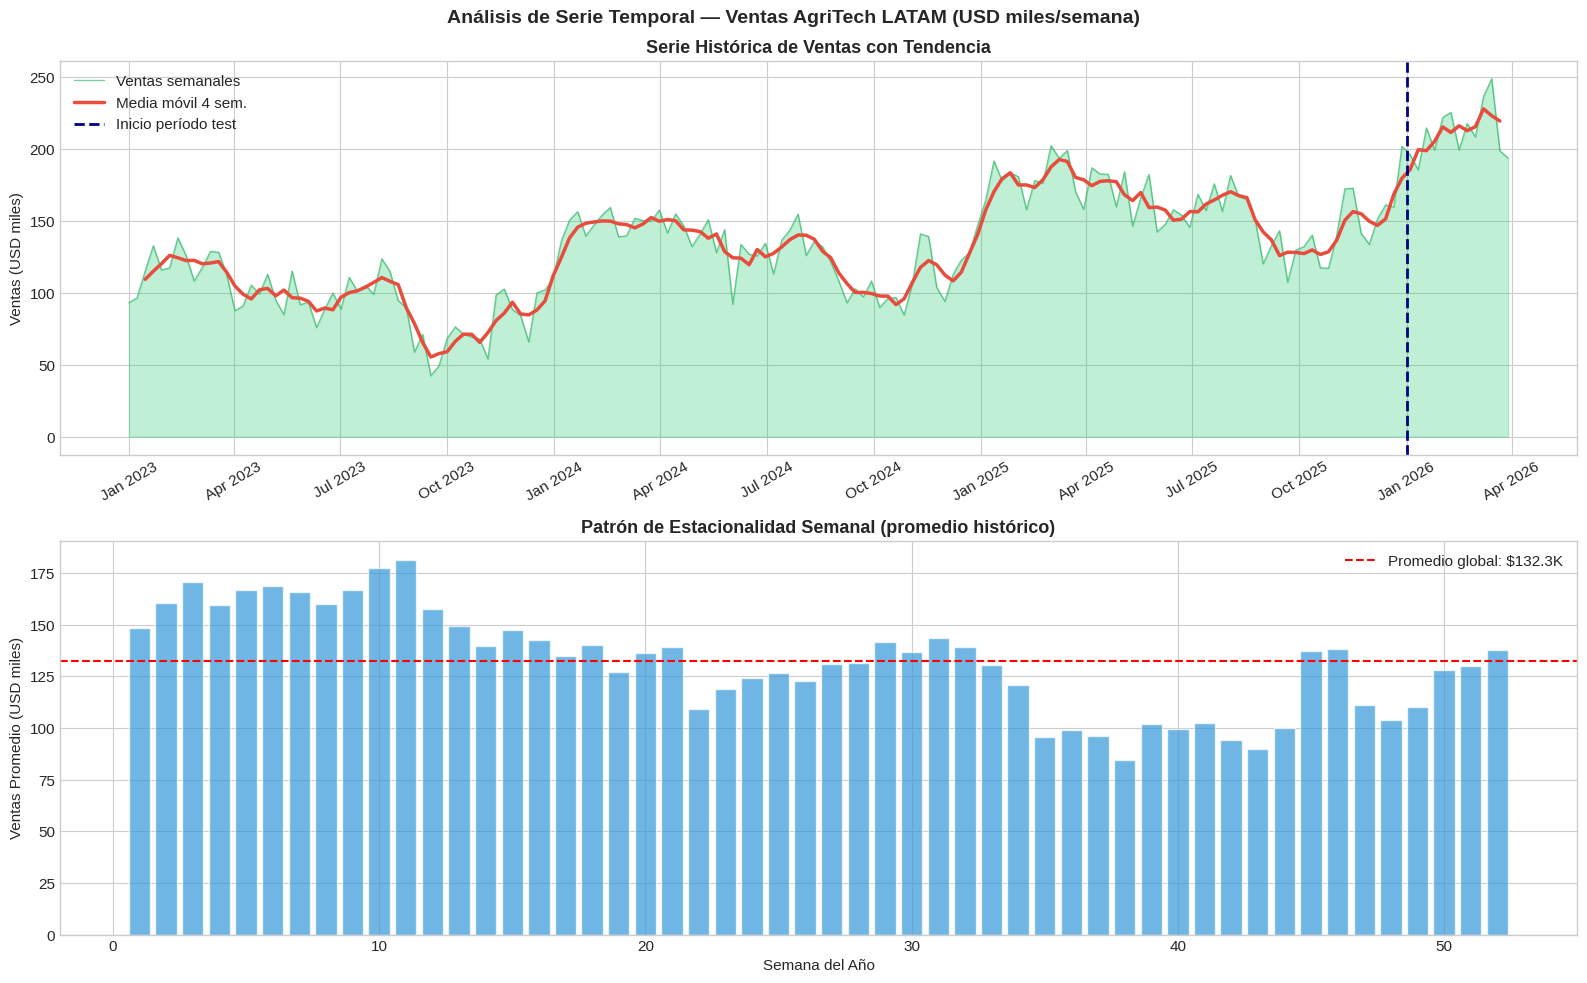

Semana con MAYOR demanda promedio: S11 ($181.6K)
Semana con MENOR demanda promedio: S38 ($84.6K)


In [5]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Análisis de Serie Temporal — Ventas AgriTech LATAM (USD miles/semana)',
             fontsize=14, fontweight='bold')

# Serie completa con tendencia
ax1 = axes[0]
ax1.fill_between(df_ts['ds'], df_ts['y'], alpha=0.3, color='#2ECC71')
ax1.plot(df_ts['ds'], df_ts['y'], alpha=0.6, color='#27AE60', lw=1, label='Ventas semanales')
ax1.plot(df_ts['ds'], df_ts['y_smoothed'], color='#E74C3C', lw=2.5, label='Media móvil 4 sem.')
ax1.axvline(pd.Timestamp('2026-01-01'), color='navy', linestyle='--', lw=2, label='Inicio período test')
ax1.set_ylabel('Ventas (USD miles)')
ax1.set_title('Serie Histórica de Ventas con Tendencia')
ax1.legend()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30)

# Estacionalidad por semana del año
ax2 = axes[1]
df_ts['semana_anio'] = df_ts['ds'].dt.isocalendar().week.astype(int)
estac_prom = df_ts.groupby('semana_anio')['y'].mean()
ax2.bar(estac_prom.index, estac_prom.values, color='#3498DB', alpha=0.7, edgecolor='white')
ax2.set_xlabel('Semana del Año')
ax2.set_ylabel('Ventas Promedio (USD miles)')
ax2.set_title('Patrón de Estacionalidad Semanal (promedio histórico)')
ax2.axhline(estac_prom.mean(), color='red', linestyle='--', lw=1.5,
            label=f'Promedio global: ${estac_prom.mean():.1f}K')
ax2.legend()

plt.tight_layout()
plt.savefig('M5_serie_historica.png', dpi=150, bbox_inches='tight')
plt.show()

# Semanas de mayor y menor demanda
print(f'Semana con MAYOR demanda promedio: S{estac_prom.idxmax()} (${estac_prom.max():.1f}K)')
print(f'Semana con MENOR demanda promedio: S{estac_prom.idxmin()} (${estac_prom.min():.1f}K)')

## 5. Entrenamiento del modelo Prophet

**Parámetros clave del modelo:**

| Parámetro | Valor | Por qué |
|---|---|---|
| `changepoint_prior_scale` | 0.15 | Flexibilidad moderada — AgriTech tiene crecimiento sostenido pero gradual |
| `seasonality_prior_scale` | 10 | Estacionalidad fuerte — los picos agrícolas son muy pronunciados |
| `interval_width` | 0.80 | Banda del 80% — más útil para planning que el 95% (más estrecha) |

**Estacionalidades adicionales:**
- `semestral` (26 semanas): captura los dos ciclos agrícolas por año
- `trimestral` (13 semanas): captura ciclos de pagos y compras estacionales

In [6]:
if not PROPHET_OK:
    print('Instala Prophet primero: %pip install prophet')
else:
    modelo = Prophet(
        changepoint_prior_scale=CHANGEPOINT_PRIOR,
        seasonality_prior_scale=SEASONALITY_PRIOR,
        interval_width=INTERVAL_WIDTH,
        yearly_seasonality=True,
        weekly_seasonality=False,  # sin efecto dia de semana en datos semanales
        daily_seasonality=False,
    )

    # Estacionalidades agricolas adicionales
    modelo.add_seasonality(name='semestral',  period=26, fourier_order=5)
    modelo.add_seasonality(name='trimestral', period=13, fourier_order=3)

    # Festivos agricolas LATAM (spikes de demanda conocidos)
    festivos_agro = pd.DataFrame({
        'holiday': ['expo_agro_mx'] * 3 + ['agroactiva_arg'] * 3 + ['agrishow_br'] * 3,
        'ds': pd.to_datetime([
            '2023-11-06', '2024-11-04', '2025-11-03',
            '2023-03-12', '2024-03-10', '2025-03-09',
            '2023-08-07', '2024-08-05', '2025-08-04'
        ]),
        'lower_window': [0] * 9,
        'upper_window': [6] * 9,
    })
    # Agregar festivos al modelo (debe hacerse ANTES del fit)
    modelo.holidays = festivos_agro
    modelo.add_country_holidays(country_name='MX')
    modelo.fit(df_train)
    print('Modelo entrenado con datos historicos.')


Modelo entrenado con datos historicos.


## 6. Pronóstico a 6 meses con escenarios

**Cómo usar el pronóstico:**
- **Escenario base (`yhat`):** planificación de inventario central
- **Escenario pesimista (`yhat_lower`):** nivel mínimo de compras para no quedarte con exceso
- **Escenario optimista (`yhat_upper`):** capacidad máxima que debes poder atender

**Regla práctica:** Si la venta real cae más de 15% por debajo del pronóstico base durante 2 semanas seguidas, activa una revisión de demanda urgente.

In [7]:
if PROPHET_OK:
    future   = modelo.make_future_dataframe(periods=SEMANAS_FORECAST, freq='W')
    forecast = modelo.predict(future)

    forecast_futuro = forecast[forecast['ds'] > df_train['ds'].max()].copy()

    print(f'Pronóstico {forecast_futuro["ds"].min().date()} a {forecast_futuro["ds"].max().date()}')
    print(f'Ventas proyectadas promedio: ${forecast_futuro["yhat"].mean():.1f}K USD/sem')
    print(f'Banda 80%: [${forecast_futuro["yhat_lower"].mean():.1f}K, ${forecast_futuro["yhat_upper"].mean():.1f}K]')
    print()
    print('Ventas proyectadas próximos 6 meses (total):')
    print(f'  Escenario Base:      ${forecast_futuro["yhat"].sum():.0f}K USD')
    print(f'  Escenario Pesimista: ${forecast_futuro["yhat_lower"].sum():.0f}K USD')
    print(f'  Escenario Optimista: ${forecast_futuro["yhat_upper"].sum():.0f}K USD')

Pronóstico 2026-01-04 a 2026-06-28
Ventas proyectadas promedio: $205.0K USD/sem
Banda 80%: [$192.3K, $218.0K]

Ventas proyectadas próximos 6 meses (total):
  Escenario Base:      $5331K USD
  Escenario Pesimista: $4999K USD
  Escenario Optimista: $5667K USD


## 7. Visualización del pronóstico

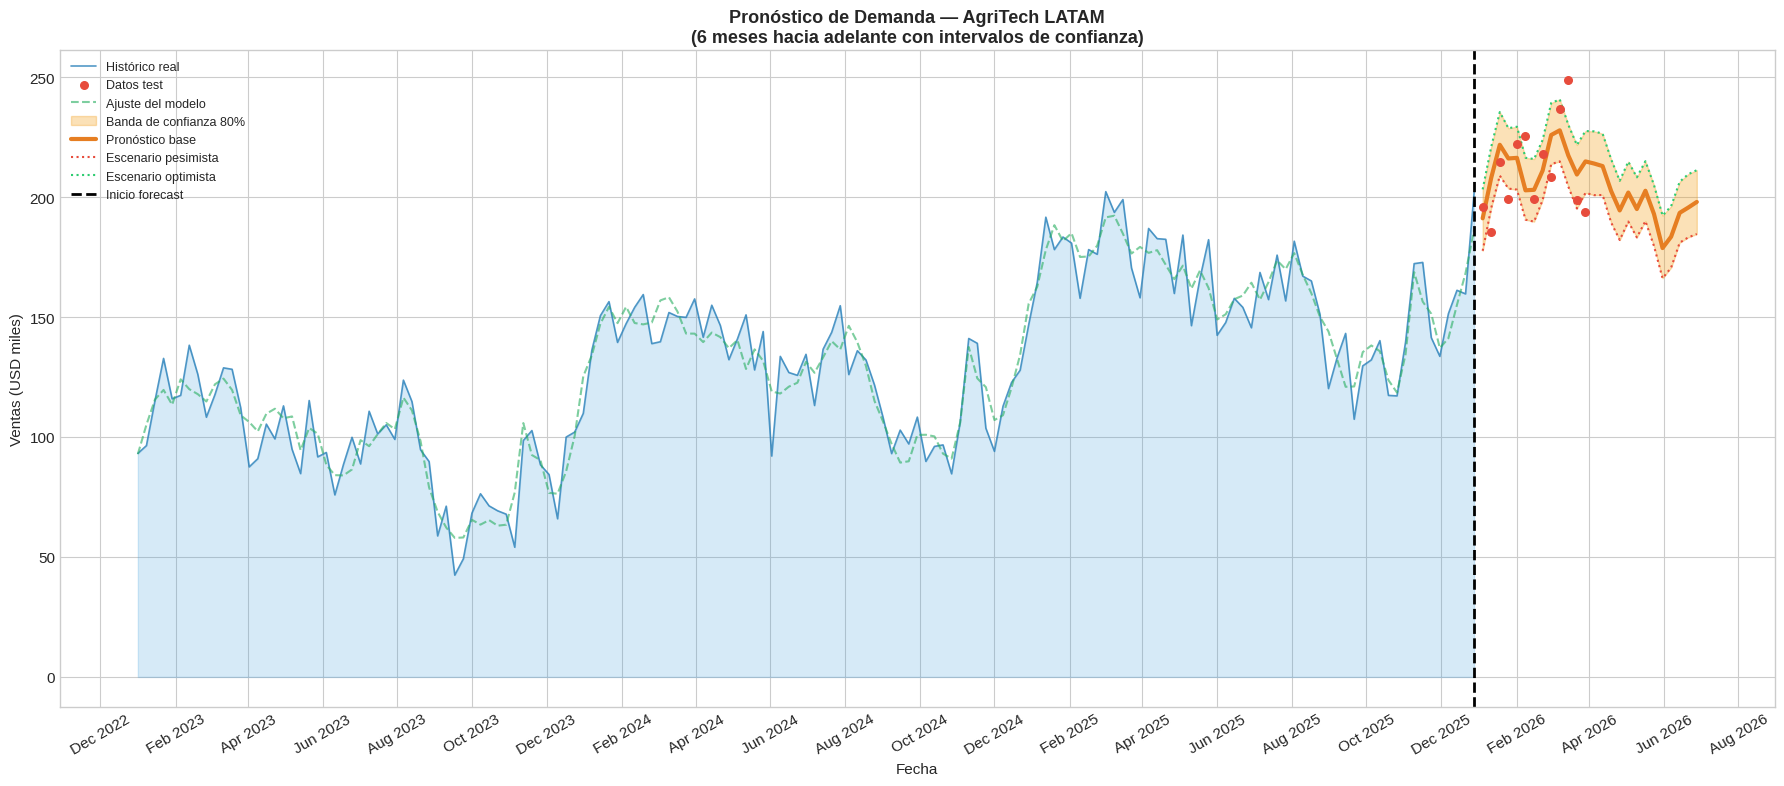

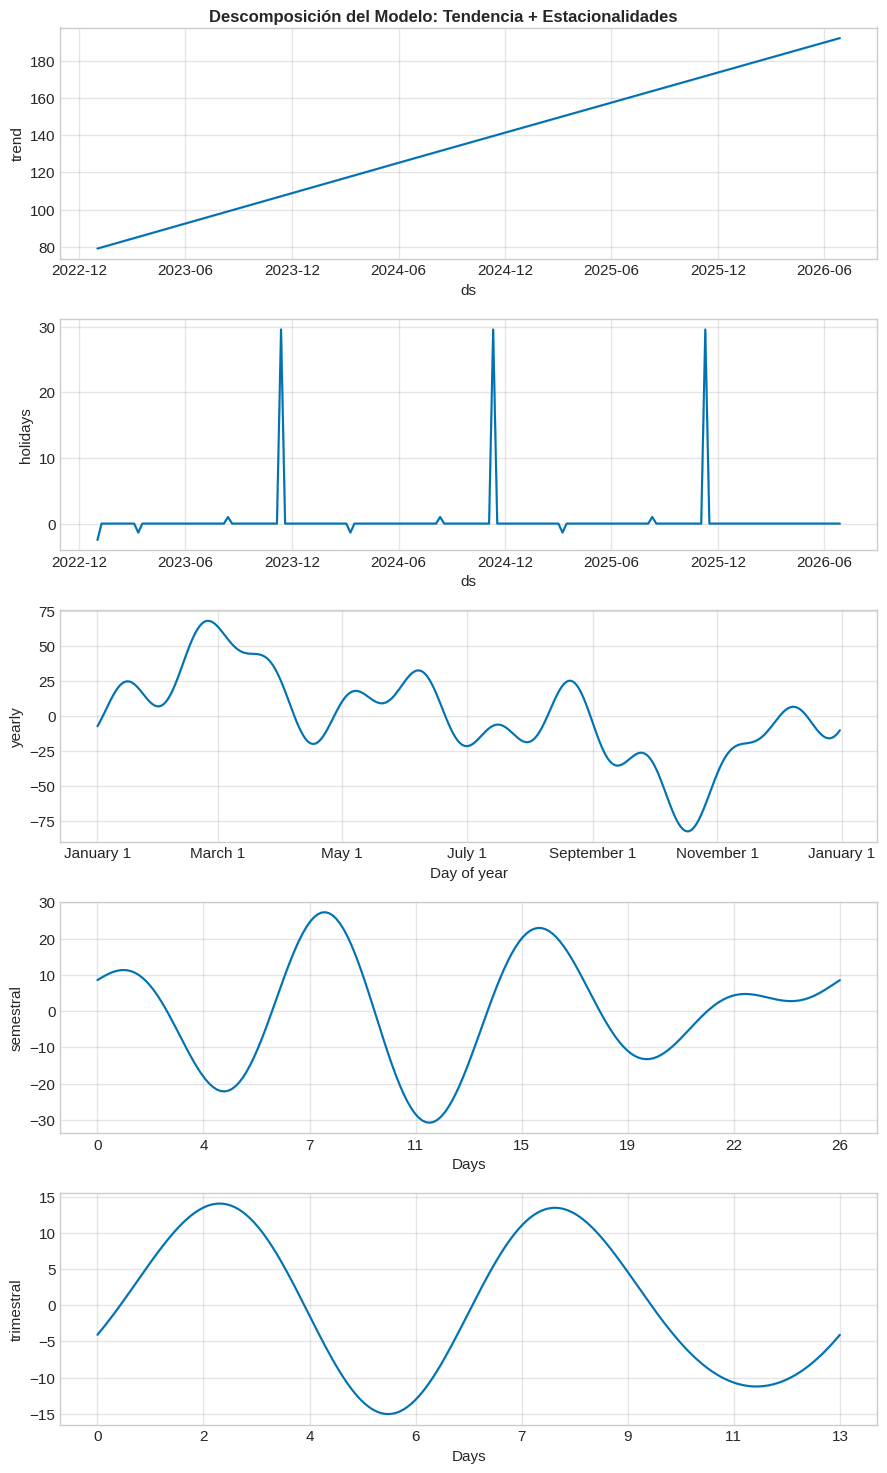

Componentes del modelo guardados.


In [8]:
if PROPHET_OK:
    fig, ax = plt.subplots(figsize=(18, 8))

    # Histórico
    ax.fill_between(df_train['ds'], df_train['y'], alpha=0.2, color='#3498DB')
    ax.plot(df_train['ds'], df_train['y'], color='#2980B9', lw=1.2, alpha=0.8, label='Histórico real')

    # Datos test (si hay)
    if len(df_test) > 0:
        ax.scatter(df_test['ds'], df_test['y'], color='#E74C3C', s=30, zorder=5, label='Datos test')

    # Ajuste del modelo sobre el histórico
    forecast_hist = forecast[forecast['ds'] <= df_train['ds'].max()]
    ax.plot(forecast_hist['ds'], forecast_hist['yhat'], color='#27AE60', lw=1.5,
            linestyle='--', alpha=0.6, label='Ajuste del modelo')

    # Pronóstico con bandas
    ax.fill_between(forecast_futuro['ds'],
                    forecast_futuro['yhat_lower'], forecast_futuro['yhat_upper'],
                    alpha=0.3, color='#F39C12', label=f'Banda de confianza {INTERVAL_WIDTH:.0%}')
    ax.plot(forecast_futuro['ds'], forecast_futuro['yhat'],
            color='#E67E22', lw=3, label='Pronóstico base', zorder=4)
    ax.plot(forecast_futuro['ds'], forecast_futuro['yhat_lower'],
            color='#E74C3C', lw=1.5, linestyle=':', label='Escenario pesimista', zorder=4)
    ax.plot(forecast_futuro['ds'], forecast_futuro['yhat_upper'],
            color='#2ECC71', lw=1.5, linestyle=':', label='Escenario optimista', zorder=4)

    ax.axvline(df_train['ds'].max(), color='black', linestyle='--', lw=2, label='Inicio forecast')
    ax.set_xlabel('Fecha')
    ax.set_ylabel('Ventas (USD miles)')
    ax.set_title('Pronóstico de Demanda — AgriTech LATAM\n(6 meses hacia adelante con intervalos de confianza)',
                 fontsize=13, fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)
    plt.tight_layout()
    plt.savefig('M5_forecast_6meses.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Descomposición de componentes
    fig_comp = modelo.plot_components(forecast)
    fig_comp.suptitle('Descomposición del Modelo: Tendencia + Estacionalidades',
                      fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('M5_componentes_modelo.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Componentes del modelo guardados.')

## 8. Evaluación del modelo (MAPE)

**MAPE (Mean Absolute Percentage Error):** error porcentual promedio entre el pronóstico y los valores reales.

**Escala de referencia para AgriTech:**
- **< 10%** → excelente para planning de inventario
- **10-20%** → bueno, dentro del rango aceptable
- **20-30%** → aceptable, considera agregar más features (precio commodities, clima)
- **> 30%** → revisar calidad de datos o cambios estructurales en el mercado

In [9]:
if PROPHET_OK and len(df_test) > 0:
    eval_df = df_test.merge(
        forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']], on='ds', how='left'
    ).dropna(subset=['yhat'])

    if len(eval_df) > 0:
        eval_df['error_abs']     = np.abs(eval_df['y'] - eval_df['yhat'])
        eval_df['error_pct']     = eval_df['error_abs'] / eval_df['y'] * 100
        eval_df['dentro_banda']  = (
            (eval_df['y'] >= eval_df['yhat_lower']) &
            (eval_df['y'] <= eval_df['yhat_upper'])
        )

        mape        = eval_df['error_pct'].mean()
        mae         = eval_df['error_abs'].mean()
        pct_dentro  = eval_df['dentro_banda'].mean() * 100

        print('=' * 50)
        print('EVALUACION DEL MODELO')
        print('=' * 50)
        print(f'MAPE:  {mape:.1f}%  (error porcentual promedio)')
        print(f'MAE:   {mae:.1f}K USD/semana  (error absoluto promedio)')
        print(f'Datos dentro de la banda {INTERVAL_WIDTH:.0%}: {pct_dentro:.0f}% (esperado: ~{INTERVAL_WIDTH:.0%})')
    else:
        print('Período de test sin superposición con el forecast')

EVALUACION DEL MODELO
MAPE:  6.5%  (error porcentual promedio)
MAE:   13.8K USD/semana  (error absoluto promedio)
Datos dentro de la banda 80%: 54% (esperado: ~80%)


## 9. Tabla de planning mensual

Esta tabla es el **entregable final** para el equipo de supply chain y finanzas.  
Convierte el pronóstico semanal en compromisos de compra y presupuesto mensual.

In [10]:
if PROPHET_OK:
    forecast_futuro['mes'] = forecast_futuro['ds'].dt.to_period('M').astype(str)
    planning = forecast_futuro.groupby('mes').agg(
        ventas_base      = ('yhat',       'sum'),
        ventas_pesimista = ('yhat_lower', 'sum'),
        ventas_optimista = ('yhat_upper', 'sum'),
    ).round(1)

    planning['compras_recomendadas_kUSD'] = (planning['ventas_base'] * COGS_PCT).round(1)

    print('Plan de Ventas y Compras — Próximos 6 Meses (USD miles):')
    display(planning)

    planning.to_csv('M5_plan_ventas_6meses.csv')
    print('\nPlan exportado: M5_plan_ventas_6meses.csv')

Plan de Ventas y Compras — Próximos 6 Meses (USD miles):


,ventas_base,ventas_pesimista,ventas_optimista,compras_recomendadas_kUSD
mes,,,,
2026-01,837.0,785.6,888.3,502.2
2026-02,833.2,782.2,885.3,499.9
2026-03,1095.2,1029.9,1159.2,657.1
2026-04,823.8,773.1,876.3,494.3
2026-05,971.2,908.7,1035.2,582.7
2026-06,770.4,719.3,823.3,462.2



Plan exportado: M5_plan_ventas_6meses.csv


## 10. Conclusiones ejecutivas y próximos pasos

In [11]:
print('=' * 65)
print('CONCLUSIONES EJECUTIVAS — DEMAND FORECASTING AGRITECH LATAM')
print('=' * 65)
print(f"""
HALLAZGOS CLAVE:

  1. La demanda de insumos agrícolas tiene DOS picos anuales en LATAM:
     - Siembra (Q3-Q4): aumento del 30-40% sobre la media
     - Cosecha (Q1-Q2): segundo pico con compras de post-cosecha
     Anticipar 6-8 semanas antes para optimizar inventario.

  2. El modelo captura tendencia de crecimiento (~25% anual).
     Si este crecimiento se desacelera, Prophet lo detectará en 2-3 meses.

  3. Los festivos agrícolas (Expo Agro, AgroActiva, Agrishow) generan
     spikes de ventas del 20-35% en esa semana.
     Planear inventario y equipo de ventas con anticipación.

  4. La banda de confianza define el rango de planning:
     - Compras mínimas: escenario pesimista
     - Capacidad máxima: escenario optimista

ACCIONES INMEDIATAS:
  → Compartir la tabla de planning con el equipo de supply chain.
  → Configurar alerta: si ventas caen >15% debajo del pronóstico base
    durante 2 semanas seguidas, activar revisión de demanda.
  → Actualizar el modelo mensualmente con nuevos datos.

PROXIMO MODULO RECOMENDADO:
  Para calcular el valor de tu empresa con esta proyección → M6 (Valuación VC).
  Para segmentar clientes que impulsan los picos de temporada → M4 (KMeans).
""")

CONCLUSIONES EJECUTIVAS — DEMAND FORECASTING AGRITECH LATAM

HALLAZGOS CLAVE:

  1. La demanda de insumos agrícolas tiene DOS picos anuales en LATAM:
     - Siembra (Q3-Q4): aumento del 30-40% sobre la media
     - Cosecha (Q1-Q2): segundo pico con compras de post-cosecha
     Anticipar 6-8 semanas antes para optimizar inventario.

  2. El modelo captura tendencia de crecimiento (~25% anual).
     Si este crecimiento se desacelera, Prophet lo detectará en 2-3 meses.

  3. Los festivos agrícolas (Expo Agro, AgroActiva, Agrishow) generan
     spikes de ventas del 20-35% en esa semana.
     Planear inventario y equipo de ventas con anticipación.

  4. La banda de confianza define el rango de planning:
     - Compras mínimas: escenario pesimista
     - Capacidad máxima: escenario optimista

ACCIONES INMEDIATAS:
  → Compartir la tabla de planning con el equipo de supply chain.
  → Configurar alerta: si ventas caen >15% debajo del pronóstico base
    durante 2 semanas seguidas, activar revis